# 04 · The efficiency lever — best vs worst intensity

**Question:** for a high-intensity commodity, how big is the gap between the most and least efficient producers? A large gap = the core 'cut impact without cutting output' lever: close the gap to best-practice.

This is the candidate **signature metric** (the Sustain analog of Grow's HHI).

> **Data hygiene:** `intensity_gap` now filters to the per-kg *intensity* element (not raw emission amounts) and trims the extreme 2% tails, and the aggregate filter now drops sub-regions like *South America*. Earlier runs showed million-x ratios — those were unit-mixing + leaked region aggregates, now fixed. Expect realistic ratios (single to low-double digits) after re-running.

## Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, matplotlib.pyplot as plt
from src import load, clean, footprint, viz

data = load.load_all()
emis, inten, land = data['emissions'], data['intensities'], data['landuse']
emis_c, _  = clean.split_countries_aggregates(emis)
inten_c, _ = clean.split_countries_aggregates(inten)
land_c, _  = clean.split_countries_aggregates(land)
YEAR = clean.pick_analysis_year(emis_c)
ELEM = clean.pick_co2eq_element(emis_c)
print('year', YEAR, '| element', ELEM)

year 2023 | element Emissions (CO2eq) (AR5)


## Intensity gap across top commodities

In [2]:
comm_int = footprint.commodity_intensity(inten_c, YEAR)
rows = []
for commodity in comm_int.head(10).index:
    g = footprint.intensity_gap(inten_c, commodity, YEAR)
    if g: rows.append(g)
gap_df = pd.DataFrame(rows)
gap_df = gap_df[['commodity','best_country','best_intensity','worst_country','worst_intensity','ratio','n_countries']]
gap_df.sort_values('ratio', ascending=False)

,commodity,best_country,best_intensity,worst_country,worst_intensity,ratio,n_countries
2,"Meat of cattle with the bone, fresh or chilled",Jordan,1.36,Mali,248.64,182.4,177
9,Rice,Benin,0.40,Ukraine,65.94,166.2,108
0,"Meat of buffalo, fresh or chilled",Egypt,6.69,Bhutan,841.10,125.7,24
1,"Meat of goat, fresh or chilled",Netherlands (Kingdom of the),3.96,New Caledonia,305.38,77.2,153
3,"Meat of sheep, fresh or chilled",Malta,3.11,Hungary,227.52,73.1,161
6,"Meat of pig with the bone, fresh or chilled",Ecuador,0.97,Burundi,32.06,32.9,158
7,Raw milk of goats,Norway,0.43,Senegal,12.93,29.9,97
4,Raw milk of camel,Ethiopia,1.99,Sudan,43.35,21.7,27
5,Raw milk of sheep,Kuwait,1.03,Mongolia,16.50,16.1,68
8,Raw milk of buffalo,Pakistan,0.83,China,4.11,5.0,15


> **The headline number** is `ratio` — e.g. 'the worst producer emits Nx more per kg than the best.' A big ratio is a strong, specific, non-obvious pitch: the emissions aren't inherent to the food, they're inherent to *how* it's produced.

## Visualize the gap for the top commodity

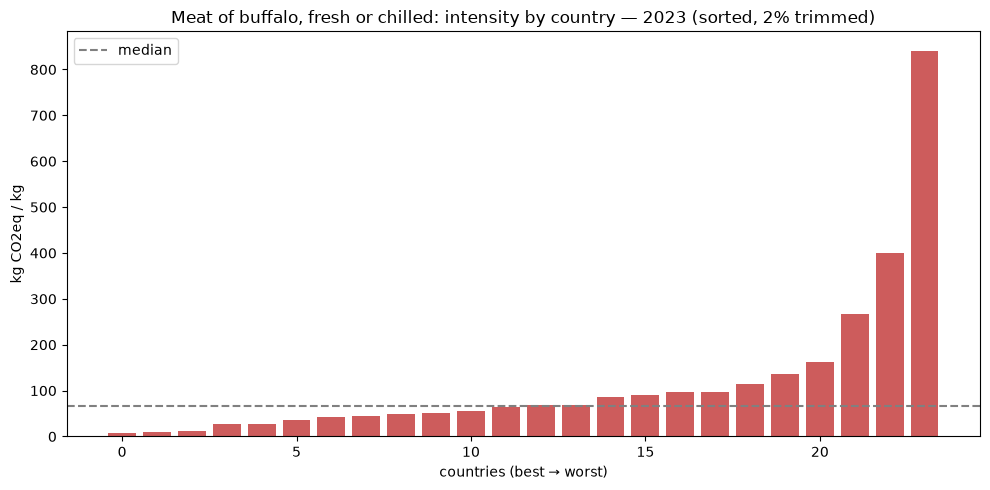

median=66.5  p10=16.3  p90=235.7  p90/p10=14.5x
(robust spread: typical-efficient vs typical-inefficient producer)


In [3]:
# Use the SAME filtered intensity path as intensity_gap (per-kg element only),
# and show a robust 10th-vs-90th percentile spread, not raw extremes.
top = comm_int.index[0]
iy_src = footprint._intensity_only(inten_c)
iy = iy_src[(iy_src['Item']==top) & (iy_src['Year']==YEAR)].groupby('Area')['Value'].median()
iy = iy[(iy>0) & iy.notna()].sort_values()
# trim 2% tails for the plot
lo, hi = iy.quantile(0.02), iy.quantile(0.98)
iy = iy[(iy>=lo) & (iy<=hi)]
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(range(len(iy)), iy.values, color='indianred')
ax.set_title(f'{top}: intensity by country — {YEAR} (sorted, 2% trimmed)')
ax.set_ylabel('kg CO2eq / kg'); ax.set_xlabel('countries (best → worst)')
ax.axhline(iy.median(), ls='--', c='grey', label='median')
ax.legend(); plt.tight_layout(); plt.show()

p10, p90 = iy.quantile(0.10), iy.quantile(0.90)
print(f'median={iy.median():.1f}  p10={p10:.1f}  p90={p90:.1f}  p90/p10={p90/p10:.1f}x')
print(f'(robust spread: typical-efficient vs typical-inefficient producer)')